In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 

import os                       #import os module

## Airy diffraction Pattern: 
( source: https://en.wikipedia.org/wiki/Airy_disk})

- Fraunhoffer diffraction pattern:

<img src="Airy-pattern.png" width=500>

- ...follows a Bessel function found by Airy:

\begin{align}
I(\theta) &= I_{0}\left[\frac{2J_{1}(x)}{x}\right]^{2}\\
        x &= ka\sin\theta = \frac{2\pi d}{\lambda}\frac{q}{R} = \frac{\pi
  q}{\lambda N}\\
  I_{0} &= \frac{P_{0} A}{\lambda^{2}R^{2}}
\end{align}

...where:
 - $I$ is the intensity, 
 - $\theta$ is the angle from the optical axis, 
 - $I_{0}$ is the intensity in the center, 
 - $J_{1}(x)$ is the first-order Bessel function of the first kind, 
 - $k=2\pi/\lambda$ is the wavenumber, 
 - $d$ is the aperture radius, 
 - $\lambda$ is the observation wavelength, 
 - $q$ is the distance from the optical axis, 
 - $R$ is the distance from the aperture center ($q/R = \sin(\theta)$),
 - $N = R/2d$ is the $f$/#, 
 - $A=\pi d^2$ is the telescope collecting area and 
 - $P_{0}$ is the total power illuminating the aperture from the point source.

- Radius of first minimum (Airy disk radius):
\begin{equation}
r_{\rm D} = \frac{1.22\lambda}{d}
\end{equation}
- The maximum intensity of the first ring is about 1.75% of the central peak intensity
- It's similar to a Gaussian

<img src="Airy_vs_gaus.png" width=500>


- Why are bright stars bigger?  (same PSF!)

- astrometry and photometry of point sources cannot be done with high precision without PSF-fitting
- a good PSF model is hard to get; may also change over course of observation due to changes on telescope  

    - In the atmosphere and for long space exposures, every image, and sometimes different parts of the same image, have a different PSF


C:\Users\Alex\AppData\Local\Temp\ipykernel_13420\3657788731.py:14: RuntimeWarning: invalid value encountered in log
  im2 = plt.imshow( np.log(d2) , cmap = 'gray')


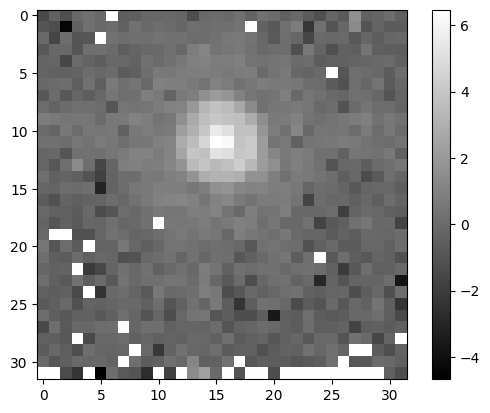

[0.69589065 0.71490885] [10.95407147 15.35136449] 721.4514846443213 [9.17453970e-04 1.31051606e-03 1.18268765e-03 1.10073364e-03
 1.14666479e+00]


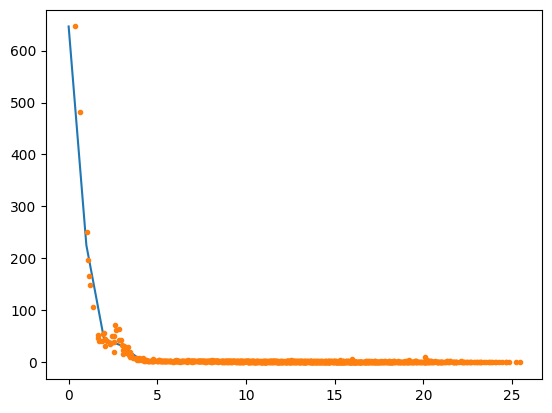

In [2]:
# 2D Gaussian centering

# psfdemo.py 
import radprof as rp
import gaussian as g

#let's get the data again:
data, hdr = fits.getdata('SPITZER_I4_15891712_0692_0000_4_bcd.fits', \
                         header=True)



d2 = data.mean(axis=0)
im2 = plt.imshow( np.log(d2) , cmap = 'gray')
#plt.xlim( 7.5, 22.5 )
#plt.ylim( 17, 2.5 )
plt.colorbar( im2 )
plt.show()

cy  =  10.
cx  =  15.
wid =   0.9
ht  = 650.
guess = ((wid, wid), (cy, cx), ht)
(fw, fc, fh, fe) = g.fitgaussian(d2 - np.median(d2), guess=guess)
print(fw, fc, fh, fe)

(bins, rp, sr, sim) = rp.radprof(d2, fc[0], fc[1])
plt.clf()
plt.plot(bins[0:20], rp[0:20])
incl = np.where(sr < 30)[0]
dm = plt.plot(sr[incl], sim[incl], '.')




### let's try to do this in an automated way:
- make a mask that isolates what could be interprated as star, but aren't of interest to us
- scan the array to find where the local max are and the source has some physical extent (>1 pixel):

C:\Users\Alex\AppData\Local\Temp\ipykernel_13420\3917032561.py:1: RuntimeWarning: divide by zero encountered in log10
  im2 = plt.imshow( np.log10(np.where( d2>1, d2, 0 ) )  , cmap = 'gray')


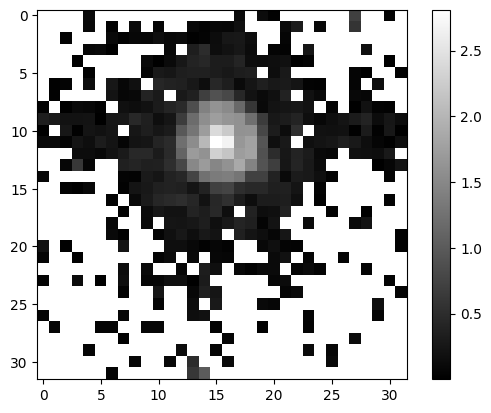

In [3]:
im2 = plt.imshow( np.log10(np.where( d2>1, d2, 0 ) )  , cmap = 'gray')
#plt.xlim( 7.5, 22.5 )
#plt.ylim( 17, 2.5 )
plt.colorbar( im2 )
plt.show()


1.094062 2 2
1.2782056 2 6
1.4544091 2 10
1.8558254 2 17
3.0638864 3 14
3.2813284 10 22
646.4692 11 15


C:\Users\Alex\AppData\Local\Temp\ipykernel_13420\4247839773.py:14: RuntimeWarning: divide by zero encountered in log10
  im2 = plt.imshow( np.log10(np.where( d2>1, d2, 0 ) )  , cmap = 'gray')


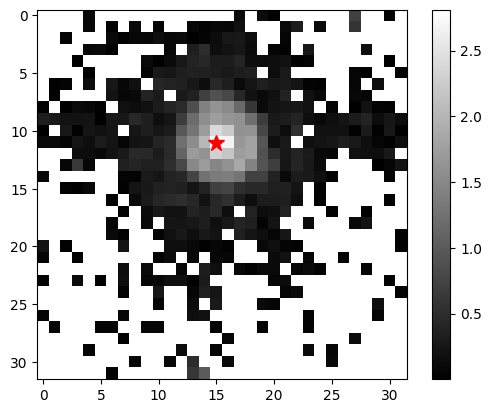

In [4]:

d2_filtered = np.where( d2>1, d2, 0 )

window = 4
peak_m = 0
for i in range( 2, 30 ):
    for j in range( 2, 30 ):
        if d2_filtered[ i, j ] == np.max( d2_filtered[ i-2: i+2, j-2:j+2  ] ):
            if np.max( d2_filtered[ i-2: i+2, j-2:j+2  ] ) > peak_m:
                peak_m = np.max( d2_filtered[ i-2: i+2, j-2:j+2  ] )
                peak_loc_y, peak_loc_x = i, j
                print( peak_m, peak_loc_y, peak_loc_x )

#plot the center:
im2 = plt.imshow( np.log10(np.where( d2>1, d2, 0 ) )  , cmap = 'gray')
plt.plot( peak_loc_x, peak_loc_y, marker = '*', markersize =12, color='red' )
#plt.xlim( 7.5, 22.5 )
#plt.ylim( 17, 2.5 )
plt.colorbar( im2 )
plt.show()

### what if you have more than one stars in your image?

In [5]:
from astropy.convolution import AiryDisk2DKernel
from astropy.convolution import Gaussian2DKernel
from astropy import units as u
from astropy.convolution import convolve_fft 

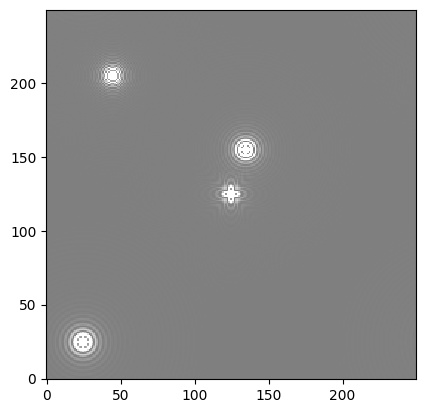

In [6]:
#let's make a scene with four stars:
airydisk_2D_kernel   = np.array( AiryDisk2DKernel(1, x_size = 250, y_size =250) )
airydisk_2D_kernel_b = np.array( AiryDisk2DKernel(3, x_size = 250, y_size =250) )
airydisk_2D_kernel_c = np.array( AiryDisk2DKernel(4, x_size = 250, y_size =250) )
airydisk_2D_kernel_d = np.array( AiryDisk2DKernel(2, x_size = 250, y_size =250) )


#first let's move few stars off center....
airydisk_2D_kernel_b = np.roll( airydisk_2D_kernel_b, 30, axis= 0 )
airydisk_2D_kernel_b = np.roll( airydisk_2D_kernel_b, 10, axis= 1 )
airydisk_2D_kernel_c = np.roll( airydisk_2D_kernel_c, -100, axis= 0 )
airydisk_2D_kernel_c = np.roll( airydisk_2D_kernel_c, -100, axis= 1 )
airydisk_2D_kernel_d = np.roll( airydisk_2D_kernel_d, 80, axis= 0 )
airydisk_2D_kernel_d = np.roll( airydisk_2D_kernel_d, -80, axis= 1 )

#make total image:
tot = airydisk_2D_kernel + airydisk_2D_kernel_b + airydisk_2D_kernel_c + airydisk_2D_kernel_d

quickmn = np.median(tot)
quicksg = np.std(tot)
nsl = -0.2
nsu = 0.2

plt.imshow(tot, interpolation='none', origin='lower', cmap='gray',
          vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg )
#plt.imshow( airydisk_2D_kernel_b , interpolation='none', origin='lower' )

In [7]:
# assume now we have a telescope with a resolution of  1 arcsec
telescope_resolution = 1*u.arcsecond
# and we have a pixel size of 1 arcsec
cdelt = 1. * u.arcsecond
# calculate the sigma in pixels. 
sigma = telescope_resolution/cdelt

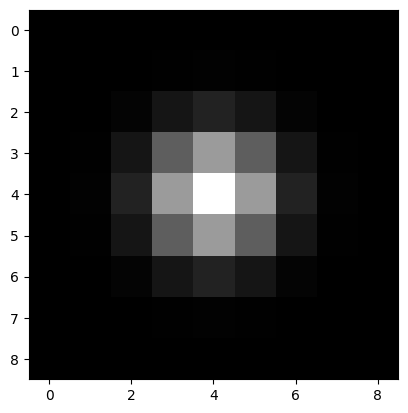

In [8]:
#let's make a PSF:
psf = Gaussian2DKernel(sigma)
# and see it:
plt.imshow(psf.array.value, cmap = 'gray')

In [9]:
#let's convolve our model image with the PSF:
convolved_image = convolve_fft( tot, psf, boundary='wrap' )

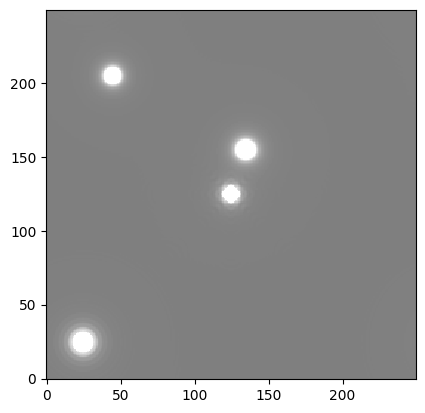

In [10]:
quickmn = np.median(convolved_image)
quicksg = np.std(convolved_image)
nsl = -0.2
nsu = 0.2

plt.imshow(convolved_image, interpolation='none', origin='lower', cmap='gray',
          vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg )

#we have our stars!

## Centering: 
- Need to know exact (sub-pixel) center of PSF for photometry. Many methods exist
    - For most stars, fit a 2D Gaussian with free $x$ and $y$ parameters
    - For Spitzer IRAC data, good to 0.02 pixels!
    - See gaussian.py in class directory
    - For very dim stars, noncircular PSFs, and non-stars, center-of-light (Howell p. 105) may be better
    

In [11]:
#let's go back and use our loop to get the centers of our stars:
window = 6
peak_threshold = 0.04

peaks_x = []
peaks_y = []

for i in range( 3, 247 ):
    for j in range( 3, 247 ):
        if convolved_image[ i, j ] == np.max( convolved_image[ i-3: i+3, j-3:j+3  ] ):
            if np.max( convolved_image[ i-3: i+3, j-3:j+3  ] ) > peak_threshold:
          #      peak_m = np.max( convolved_image[ i-2: i+2, j-2:j+2  ] )
                peaks_y.append( i ) 
                peaks_x.append( j )
                
                
                print( peak_m, peaks_y, peaks_x )

646.4692 [25] [25]
646.4692 [25, 125] [25, 125]
646.4692 [25, 125, 154] [25, 125, 134]
646.4692 [25, 125, 154, 205] [25, 125, 134, 44]


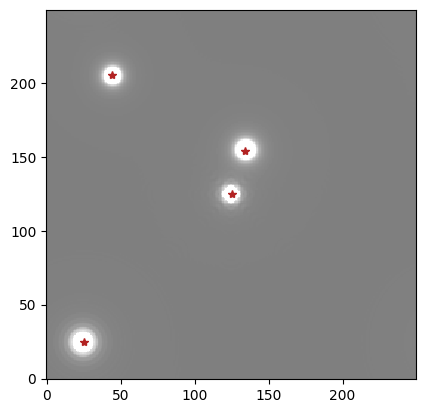

In [12]:
#let's plot our star centers:
plt.imshow(convolved_image, interpolation='none', origin='lower', cmap='gray',
          vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg )
for i in range( len( peaks_x) ):
    plt.plot( peaks_x[i], peaks_y[i], marker ='*', color = 'firebrick')

In [13]:
from scipy.ndimage import maximum_filter

In [14]:
#let's do this in a funct:
def star_finder(sigma, image, threshold):

    #let's make the PSF as a mask:
    psf      = np.array( Gaussian2DKernel(sigma) )
    psf_filt = psf >1e-3

    # find local max:
    loc_max = maximum_filter(image, footprint=psf_filt) 
    #make sure peak is a local max & above a give threshols as before:
    peaks = np.where((image == loc_max) & (image >= threshold)) 
    peaks = np.array([peaks[0],peaks[1]]).T
    
    return peaks

In [15]:
stars = star_finder( sigma, convolved_image, 0.04 )

print(len(stars))


4


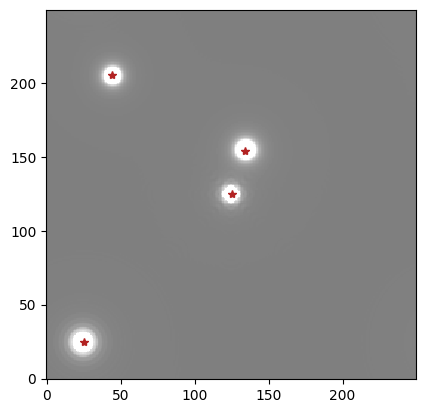

In [16]:
plt.imshow(convolved_image, interpolation='none', origin='lower', cmap='gray',
          vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg )
for i in range( len( stars )):
    plt.plot( stars[i, 1], stars[i, 0], marker ='*', color = 'firebrick')

### Why do we care? we need to know where our stars are in our image for our photometry (see next lectures)


### Generally, if no Gaussian would make sense you can follow (see Howell Ch 5):
- Start with a rough pointer to the position of the center of the target 
- the intensity of each pixel within a small box centered on the image and of size 2L+1×2L+1 (where L is comparable to the size of the PSF) are summed in both x and y directions and calculate:
    - $I_i = \sum_{j=-L}^{j=L} I_{ij}$ & $J_j = \sum_{i=-L}^{i=L} I_{ij}$
- get mean intensity: $\bar{I} = \frac{\sum_{i=-L}^{i=L} I_{i}}{2L+1} $ & $\bar{J} = \frac{\sum_{j=-L}^{j=L} J_{j}}{2L+1} $
- get coordinates of intensity weighted center: $x_c = \frac{\sum_{i=-L}^{i=L} (I_{i}-\bar{I})x_i}{\sum_{i=-L}^{i=L} I_{i}-\bar{I}} $ & $y_c = \frac{\sum_{j=-L}^{j=L} (J_{j}-\bar{J})y_j}{\sum_{j=-L}^{j=L} J_{j}-\bar{J}} $ for $I_{i}-\bar{I}> 0$ and $J_{j}-\bar{J}>0$

## Let's look a bit more into the data formation model (``A Star is Born...In Python'')

- Data formation model: a description of what contributes to a hypothetical signal
<br>
- For example: A background of 300 DN, a star with width 2.3 pixels and height 1000 DN located at position (34, 54).  
- Poisson noise with gain = 7.8 e$^-$/DN
- Read noise $\sigma_{\rm r}$ = 3 e$^-$
- Consider this noiseless model of a star in 1 dimension
- This might look like an infrared image after sky image subtraction
- Need to assess average background in blue region, subtract from each pixel:

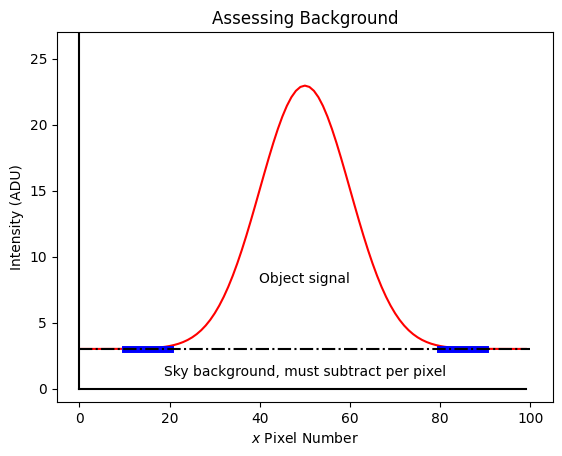

In [17]:
nx   = 100
sky  =   3.
star = 500.
ctr  = nx / 2
sig  =  10

x = np.arange(nx)
data = sky + star / np.sqrt(2. * np.pi * sig**2) * np.exp(-0.5 * ((x - ctr) / sig)**2)
plt.plot(x, data, 'r')
plt.plot(x, 0 * x, 'k')
plt.plot([0,0], [0,100], 'k')
plt.plot([ctr-4*sig, ctr-3*sig], [sky, sky], 'b', linewidth=5)
plt.plot([ctr+4*sig, ctr+3*sig], [sky, sky], 'b', linewidth=5)
plt.plot([ctr-5*sig, ctr+5*sig], [sky, sky], 'k-.')
plt.text(ctr, sky / 3., "Sky background, must subtract per pixel", horizontalalignment='center')
plt.text(ctr, sky + star / 100., "Object signal", horizontalalignment='center')
plt.xlabel('$x$ Pixel Number')
plt.ylabel('Intensity (ADU)')
plt.title('Assessing Background')
dm = plt.ylim(-1, 27)


In [18]:
#%matplotlib 

In [19]:
from mpl_toolkits.mplot3d import Axes3D
import gaussian as g
import radprof as R
import disk as d
import matplotlib.patches as pat


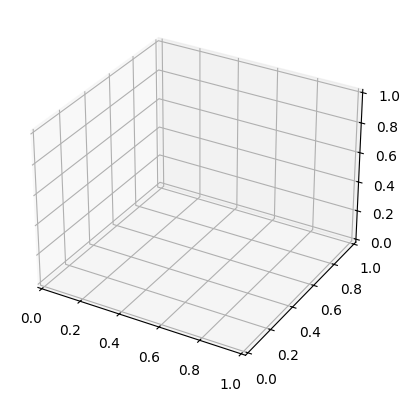

<Figure size 640x480 with 0 Axes>

In [20]:
f3D = 1
fig = plt.figure(f3D)
ax = fig.add_subplot(111, projection='3d')

f2D = 2
im = plt.figure(f2D)

# plotting defaults
cmap = 'summer_r'
rstride = 3
cstride = 3
kwargs = {"cmap":cmap, "rstride":rstride, "cstride":cstride}

# Utility function to put up a 2D and a 3D plot
def show2d3d(im2d, title, f2, f3, ax, x, y, kwargs):
#    figtitle = title.replace(" ", "-")

  # 2D figure
    plt.figure(f2)
    plt.clf()
    plt.imshow(im2d, origin="lower", interpolation='none')
    #if im2d.dtype != bool:  # colorbar breaks on bool due to deprecated math
    plt.colorbar()
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.show()
    
    # 3D figure ; w. fixed bug of apphotdemo.py
    
    
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(x, y, im2d.reshape(x.shape), 
                    cmap = 'YlGnBu')

    ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

    ax.set_title(title)
    plt.show()



In [21]:
# make some fake data

# size of image
ny = 50
nx = 50

# star properties
cy       = 22.9
cx       = 21.2
seewidth = 3.
starlev  = 1e4 # somewhat noisy, peak comparable to sky

# sky property (only one)
skylev  = 1e2

# a bad pixel
by     = 33
bx     = 38
badlev = 300.

# coordinate index arrays, for doing math
coo = np.indices((ny, nx))
y, x = coo

# make the sky
skysignal = np.zeros((ny, nx)) + skylev
skynoise  = np.sqrt(skylev) * np.random.normal(size=(ny, nx))
skyim     = skysignal + skynoise
print(np.std(skynoise))

# make the star
starsignal = starlev * g.gaussian(coo, (seewidth, seewidth), (cy, cx)) + skylev
starnoise  = np.sqrt(starsignal) * np.random.normal(size=(ny, nx))
starim     = starsignal + starnoise
print(np.sum(starim))

# add the bad pixel, make it as big as the whole star
starim[by, bx] = badlev

show2d3d(skysignal,  "Sky Signal",  f2D, f3D, ax, x, y, kwargs)


10.046146843282147


AttributeError: module 'numpy' has no attribute 'product'

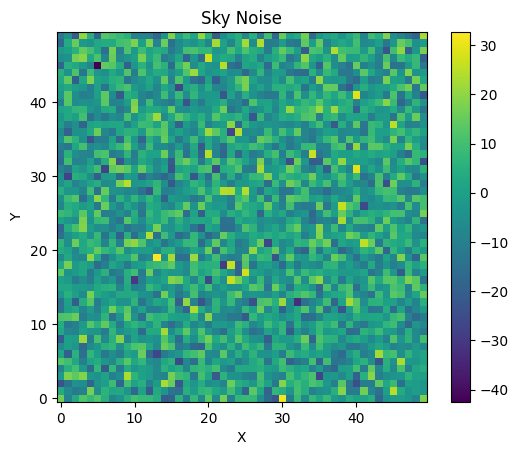

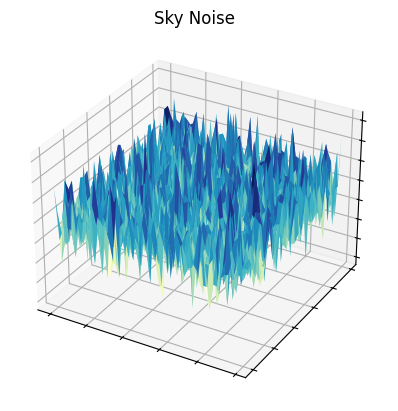

In [ ]:
show2d3d(skynoise,   "Sky Noise",   f2D, f3D, ax, x, y, kwargs)

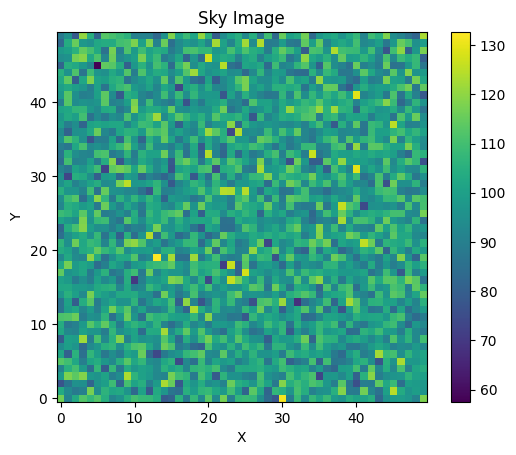

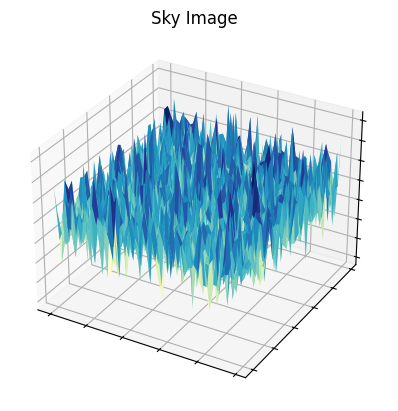

In [ ]:
show2d3d(skyim,      "Sky Image",   f2D, f3D, ax, x, y, kwargs)

In [ ]:
show2d3d(starsignal, "Star Signal", f2D, f3D, ax, x, y, kwargs)

NameError: name 'starsignal' is not defined

In [ ]:
show2d3d(starnoise,  "Star Noise",  f2D, f3D, ax, x, y, kwargs)

NameError: name 'starnoise' is not defined

In [ ]:
show2d3d(starim,     "Star Image",  f2D, f3D, ax, x, y, kwargs)

NameError: name 'starim' is not defined

In [ ]:
# Identify center using Gaussian centering
# Note that we subtract the median (approximate sky) to make Gaussian
# wings go to zero.  We'll do a better job with the sky once we have a
# better center.
guess = ((seewidth, seewidth), (cy, cx), starim.max())
(fw, fc, fh, fe) = g.fitgaussian(starim - np.median(starim), guess=guess)
print("  wy          wx            cy           cx           height")
print(fw, fc, fh)
print(fe)

# look at radial profile
(bins, rp, sr, sim) = R.radprof(starim, fc[0], fc[1])
frp = 3
plt.figure(frp)
plt.clf()
pbin = 30
incl = np.where(sr <= pbin)[0]
plt.plot(sr[incl], sim[incl], '.r')
plt.plot(bins[0:pbin], rp[0:pbin], '-k')
plt.xlabel('Distance (pix)')
plt.ylabel('Intensity (DN)')
plt.title('Radial Profile')
#plt.savefig('Radial_Profile.png')


NameError: name 'starim' is not defined

# -----------------------------------

### ICA (40 min): 

### Make a 2D array containing two10,000-element arrays with y and x input values as follows:
- For x, generate a Gaussian distribution of 10,000 values with σ = 1 and mu = 1
- For y use Poisson with a sample of 10,000 values and subsample of N = 500
- Calculate f (x, y) = sin(x) * exp(-y/1000) 
<br>

- Part A:
    - Plot the histogram of f using 50 bins and make a PNG file of the plot
    
    
- Part B:
    - Estimate < f > and its error by fitting a Gaussian to the histogram to find the center and width. Print these values. The histogram is skewed, which is the point of this exercise. You will have to restrict the fit to the region near the peak. You will also need to include a region of zero-valued bins wherever there are no data, or the fit will be wrong.
        - See gaussian.py for a routine to fit a Gaussian. 
        - Plot the fit on top of the histogram in each case and save a PNG file.
    
    - Make histograms of the y and x input arrays, fit them, and print the means and standard deviations. 
    
- Part C:
    - Use analytical formulae to calculate f and its error using the mean x and y values estimated in the previous problem. How do your “traditional” value and error differ from your Monte Carlo values? Comment on the benefits and limitations of the Monte Carlo approach in this case. Which is more correct, analytical or Monte Carlo?

# -----------------------------------

### Coding example weird data: 
### Read data from file *mixed_data.dat*. These are some models that have a few bugs in them. All values should be positive and not NaN. Read in the file with pandas and clean the data. Exclude all wavelengths for which any of the 4 models are negative or NaNs.

In [ ]:
#data_f = 'mixed_data.dat'

#read in data using pandas (note there is function to read csv files)
#dat    = pd.read_csv( data_f )

In [ ]:
#pandas have functions to remove NaNs:
# compare: notna() with dropna() 

#test:
#nan_mask = dat.notna()

#print( nan_mask)
#print( dat[ nan_mask ])

In [ ]:
#vs:
#dat = dat.dropna( thresh=5 )

In [ ]:
#remember that with pandas you can use 'describe' to see your data
#dat.describe

In [ ]:
#if you didn't use pandas, but numpy, how would you check if a value is NaN?

In [ ]:
#remove negative data (use the power of pandas)

#you can hardcode the headers to loop over them, or you can use 
#an automated loop (not big dif here, huge one when you have *lots* of data)

#heads = []
#for col in dat.columns:
#    heads.append( col )


In [ ]:
#dat_cleaned = dat[ dat[ heads ].min( axis = 1  ) >=0 ]

In [ ]:
#print( dat_cleaned )
#how would you do it if you had opted for numpy

In [ ]:
# WORK ON MIDTERM PLEASE :)

# -----------------------------------

### Toward photometry

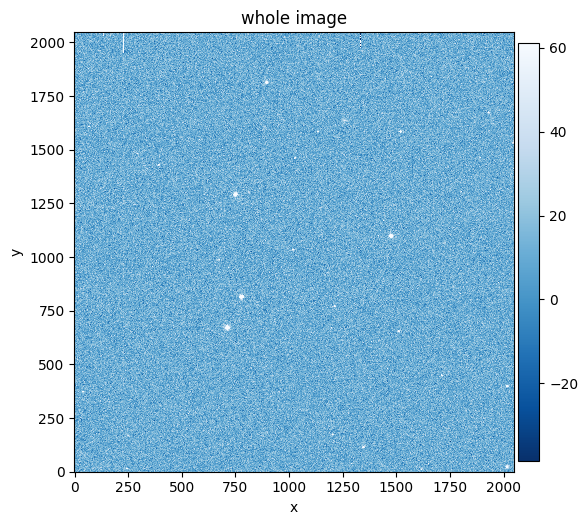

In [ ]:
#!/usr/bin/env python3
# More basics of FITS files
# October 24, 2022
# by Yan Fernandez for AST 4762/5765. 
# updates to python coding TK
"""Some info about PSFs and 2-D gaussian fitting"""
#----------------------------------------------------------------------------
#This program demonstrates some basic things about a PSF.
#It uses an image of a star, since this particular data was
#taken with a ground-based telescope. So the PSF is created
#by the seeing effect, not the diffraction effect. I.e. the
#atmospheric conditions at the time controlled what the PSF looks like.
#----------------------------------------------------------------------------
#----usually things to import first:
#from numpy import polynomial
#import math
#import matplotlib.pyplot as plt
#from scipy import special
#from scipy import stats
#from scipy.stats import chi2
#import sys
#----for reading in and writing out FITS files:
#import astropy
#from astropy import io
#from astropy.io import fits
#----for doing some fitting:
from astropy import modeling
#----for doing some centroiding:
#import photutils
#from photutils.centroids import centroid_com, centroid_2dg
#import copy

#----------------------------------------------------------------------------
#First let's get an image that we'll play around with.
#It's a clean, science-quality image, so we don't need to
#do the de-biasing and flat-fielding.
#For Yan's refernece, it is frame nt2.034cl.fits from uh88-2005junandjul/nt2raw
fil = 'examplecleanimage.fits'
with fits.open(fil) as img:
    cleanimg = img[0].data



#trim off the overscan, easier to just not have it at all.
cleanimg = cleanimg[0:2048,19:2067]
#check for any non-finite pixels, and replace them.
#sometimes that happens because occasionally a flat field pixel
#is identically zero.
#whinf = np.where( np.isfinite(cleanimg) != 1 )
#cleanimg[whinf] = np.median(cleanimg)
cleanimg = np.where( np.isfinite(cleanimg) != 1, np.median(cleanimg), cleanimg )

#now show the image using vmin/max stretching
qm = np.median(cleanimg)
qs = np.std(cleanimg)
plt.figure( figsize = (6,6 ))
im2 = plt.imshow(cleanimg, interpolation='none', origin='lower', 
           vmin=qm-0.2*qs, vmax=qm+0.2*qs, cmap='Blues_r')
plt.colorbar( im2 ,fraction=0.045, pad=0.01)
plt.xlabel("x")
plt.ylabel("y")
dm = plt.title("whole image")


In [ ]:
#----------------------------------------------------------------------------
#subtract off the overall sky brightness, and isolate one of the stars
#into a subarray. the star is the one towards the upper left, and is
#near x=745, y=1285.
#pull out the star.
subsz = 7 #we'll make just a 15-by-15 array.
startsuby = 1291
startsubx = 752
sub = cleanimg[startsuby-subsz:startsuby+subsz+1, 
               startsubx-subsz:startsubx+subsz+1] # remember, flip x and y
# subtract off the sky's brightness.
sub = sub - np.median( cleanimg )
#but note that this is not really the proper way to do this!
#we will do the sky assessment and subtraction in a more rigorous way later.
#----------------------------------------------------------------------------
#now do the 2D gaussian fitting
#we help the procedure along by giving it some input numbers that are
#close to the right answer. the five parameters to give it are:
# amplitude = max of the PSF.
# x_mean and y_mean = location of the center of the 2D gaussian.
# x_stddev and y_stddev = the sigmas to the two gaussians.
#
#in addition, this 2D gaussian routine finds "theta", the angle
#that the 2D gaussian is tilted with respect to the x-axis. But we
#don't need to give a guess at that as input.
#first guess on amplitude is easy.
ampl_firstguess = np.max( sub )
#first guess for the center is also easy, it's just where the max occurs:
whmax = np.where( sub == np.max(sub) )
xmean_firstguess = whmax[0][0]
ymean_firstguess = whmax[1][0]
#first guess for the stddev is a little trickier. Note that you
#can't just do np.std of the image -- that's not what we need, since
#that's finding std of the pixel values. What we need is an estimate
#of how wide the image actually is. So let's find how far you are
#when the image drops to 1/2 the max brightness. To do that, we
#can make what I usually call a "rho" array. "rho" in this case
#gives the distance that a particular pixel is away from the maximum pixel.
#Making the rho array is easy:
sy, sx = np.indices( sub.shape )
rho = np.sqrt( (sx - xmean_firstguess)**2 + (sy - ymean_firstguess)**2 )
#now use the where function to find where in the rho array we're
#halfway down from the peak.
whhalf = np.where(sub >= np.max(sub)*0.5)
xstd_firstguess = np.max(rho[whhalf])
ystd_firstguess = xstd_firstguess


In [ ]:
#now we're ready to fit:
fitter = modeling.fitting.LevMarLSQFitter()
model = modeling.models.Gaussian2D( amplitude = ampl_firstguess, x_mean = xmean_firstguess, 
                                   y_mean = ymean_firstguess, x_stddev = xstd_firstguess, 
                                   y_stddev = ystd_firstguess )
fitted_model = fitter( model, sx, sy, sub )
#here are the actual answers for the best fitting 2D gaussian:
bestamp = fitted_model.amplitude[0]
bestxmn = fitted_model.x_mean[0]
bestymn = fitted_model.y_mean[0]
bestxsg = fitted_model.x_stddev[0]
bestysg = fitted_model.y_stddev[0]
bestth = fitted_model.theta[0]
print("best fitting 2D gaussian: ")
print(" height : %7.1f" % (bestamp))
print(" x,y of center: %4.2f , %4.2f" % (bestxmn, bestymn))
print(" x,y widths : %4.2f , %4.2f" % (bestxsg, bestysg))
print(" orientation : %6.2F deg" % (bestth*180./np.pi))
#what's the difference between data and model?
diff = sub - fitted_model(sx, sy)


best fitting 2D gaussian: 
 height : 11971.5
 x,y of center: 7.13 , 7.15
 x,y widths : 1.79 , 1.36
 orientation :   2.89 deg


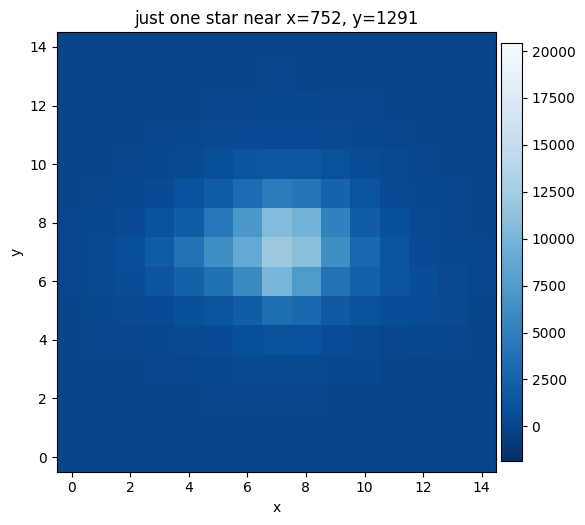

In [ ]:
#----------------------------------------------------------------------------
#now show the results with a variety of plots.
#here's the original star:
qm = np.median(sub)
qs = np.std(sub)
plt.figure( figsize = (6, 6 ))
im3 = plt.imshow(sub, interpolation='none', origin='lower', 
                 vmin=qm-1.0*qs, vmax=qm+10.0*qs, cmap='Blues_r')
plt.title("star image")
plt.xlabel("x")
plt.ylabel("y")
plt.title("just one star near x=752, y=1291")
dm = plt.colorbar(im3 ,fraction=0.045, pad=0.01)


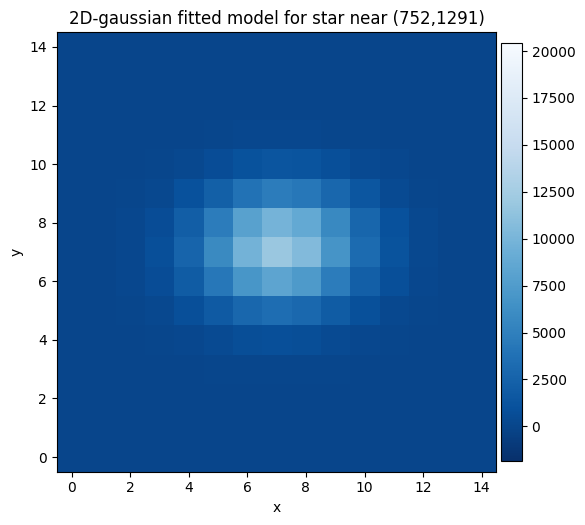

In [ ]:
#here's the best fitting model:
plt.figure( figsize = ( 6,6 ) )
im4 = plt.imshow(fitted_model(sx, sy), interpolation='none', origin='lower', 
           vmin=qm-1.0*qs, vmax=qm+10.0*qs, cmap='Blues_r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D-gaussian fitted model for star near (752,1291)")
dm = plt.colorbar( im4 ,fraction=0.045, pad=0.01 )


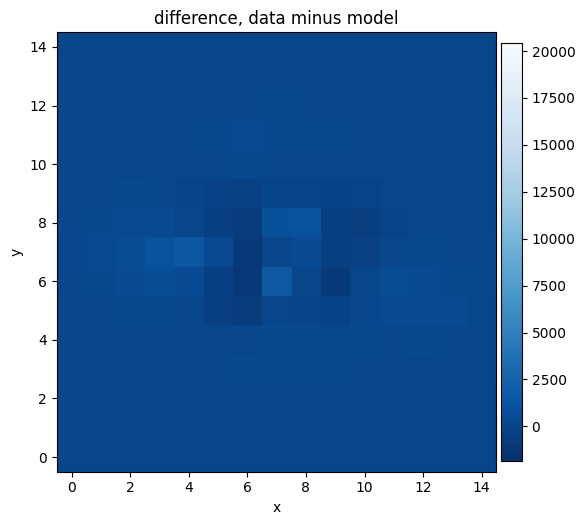

In [ ]:
#and here's the difference
plt.figure( figsize = (6,6) )
im5 = plt.imshow(diff, interpolation='none', origin='lower', 
                 vmin=qm-1.0*qs, vmax=qm+10.0*qs, cmap='Blues_r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("difference, data minus model")
dm = plt.colorbar( im5 ,fraction=0.045, pad=0.01 )


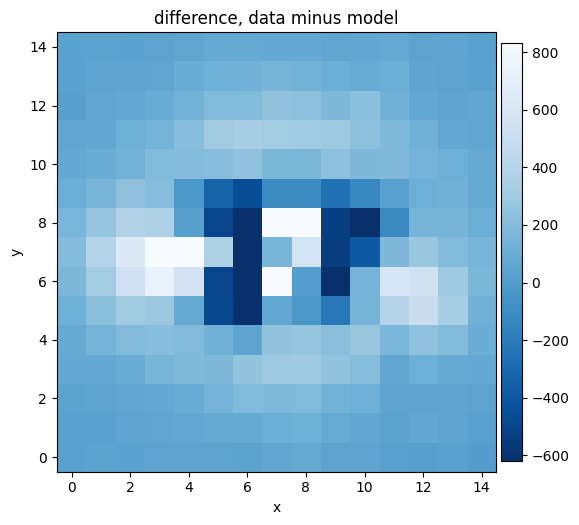

In [ ]:
#difference as displayed with its own scaling.
qm = np.median(diff)
qs = np.std(diff)
plt.figure( figsize = (6,6 ))
im6 = plt.imshow(diff, interpolation='none', origin='lower', 
           vmin=qm-2.5*qs, vmax=qm+2.5*qs, cmap='Blues_r')
plt.xlabel("x")
plt.ylabel("y")
plt.title("difference, data minus model")
dm = plt.colorbar( im6 ,fraction=0.045, pad=0.01 )

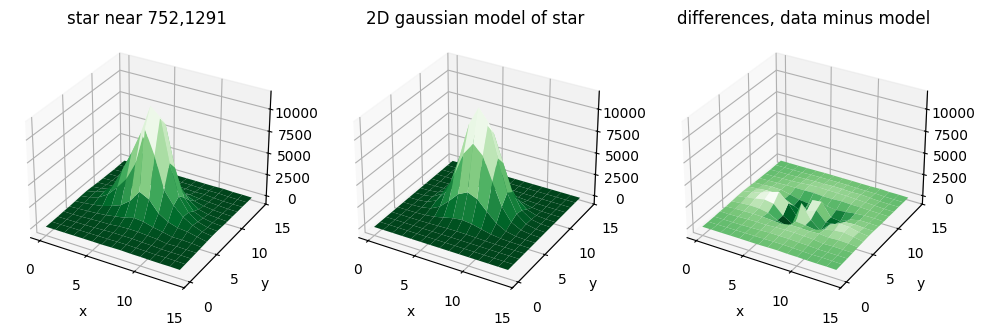

In [ ]:
#show all this as surface plots.
fig = plt.figure( figsize=(12,6) ) 
ax = fig.add_subplot(1,3,1, projection="3d")
ax.plot_surface(sx, sy, sub, cmap='Greens_r')
ax.set_zlim(-1000,12000)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("star near 752,1291")


ax = fig.add_subplot(1,3,2, projection="3d")
ax.plot_surface(sx, sy, fitted_model(sx, sy), cmap='Greens_r')
ax.set_zlim(-1000,12000)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("2D gaussian model of star")


ax = fig.add_subplot(1,3,3,projection="3d")
ax.plot_surface(sx, sy, diff, cmap='Greens_r')
ax.set_zlim(-1000,12000)
ax.set_xlabel("x")
ax.set_ylabel("y")
dm = ax.set_title("differences, data minus model")


In [ ]:
#----------------------------------------------------------------------------
#now let's look at the radial profile of the PSF.
#to do this, let's look at a little bit bigger chunk of the image
#than just the 15-by-15 area around that star. let's make it
#more like 200-by-200.
#so we'll need a new "rho" array too.
offset = 100 # so total pixels are 2*offset
sub2 = cleanimg[startsuby-offset:startsuby+offset, 
                startsubx-offset:startsubx+offset]
#later on we will use centroiding to find the center of
#an image more easily. For now, let's go with the same
#method we did before, just use the pixel of maximum brightness
#as the center, and calculate rho from that.
whmax = np.where( sub2 == np.max(sub2) )
xctr = whmax[0][0]
yctr = whmax[1][0]
sy2, sx2 = np.indices(sub2.shape)
rho2 = np.sqrt((sx2 - xctr)**2 + (sy2 - yctr)**2)


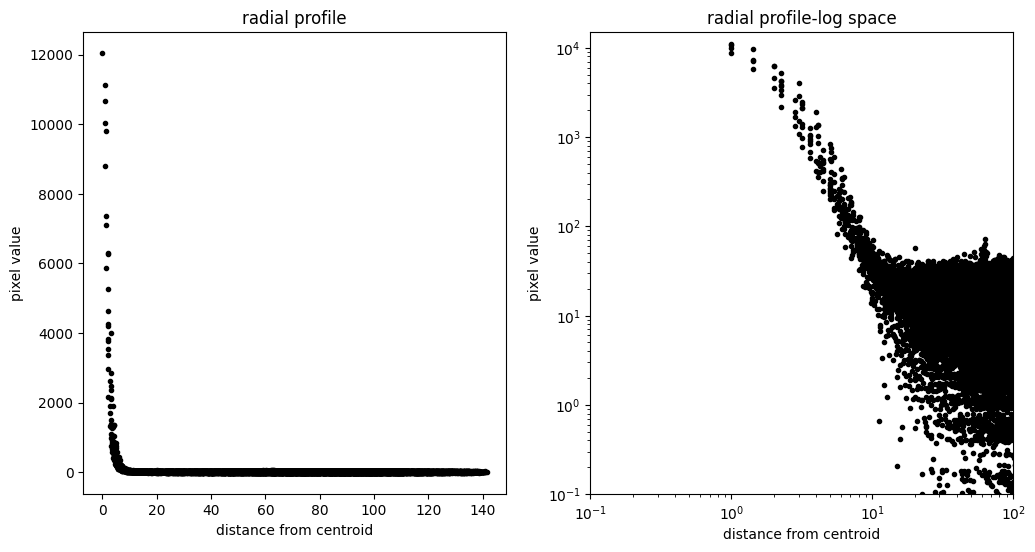

In [ ]:
#now plot the radial profile. each dot is one pixel in the image.
fig,ax = plt.subplots( 1,2, figsize = (12, 6) )
ax[0].plot(rho2, sub2, '.', color='Black')
ax[0].set_xlabel("distance from centroid")
ax[0].set_ylabel("pixel value")
ax[0].set_title("radial profile")

#now plot in log space.

ax[1].loglog(rho2, sub2, '.', color='Black')
ax[1].set_xlabel("distance from centroid")
ax[1].set_ylabel("pixel value")
ax[1].set_title("radial profile-log space")
ax[1].set_xlim(0.1,100)
dm = ax[1].set_ylim(0.1,15000)
#plt.xscale("log")
#plt.yscale("log")
#plt.show()
#----------------------------------------------------------------------------
#end of program


In [ ]:
import disk as d

nx = 50
ny = 50

### Choosing the Star Aperture and Sky Annulus: 
- We want to estimate the flux of the star
- Some background remains (even with sky image subtraction)
- How far out from star center to count?
- Establish center accurately (see Centering)
- Look at radial profile of star
- Want all of starlight, but minimal sky noise
- How far out to count? (see radial profile)
- The optimal aperture size for best S/N varies with S/N (see below)
- Must do same apertures for all stars to avoid systematic error
- Often, we compare photometry done with different apertures
- Check your aperture size!
- Establish $\sigma$ using bright star (why bright?)
- Use `gaussian.fitgaussian()` or just do FWHM and convert
- Count DN within 3-4$\sigma$ from center for star
- Count DN in sky annulus farther out
- Want many more sky pixels than aperture pixels for better S/N


In [ ]:
# Set aperture, sky inner and outer radii
aprad  = 12.
skyin  = 15.
skyout = 25.

# make a mask of bad pixels
badpix  = np.ones((ny, nx), dtype=np.bool)
badpix[by, bx] = False

# Make masks
apmask  =   d.disk(aprad,  fc, starim.shape)
skymask =   d.disk(skyout, fc, starim.shape) \
          ^ d.disk(skyin,  fc, starim.shape)

apmask  *= badpix
skymask *= badpix

show2d3d( apmask, "Aperture Mask",     f2D, f3D, ax, x, y, kwargs)
show2d3d(skymask, "Sky Annulus Mask",  f2D, f3D, ax, x, y, kwargs)
# NOTE: If bad pixel appears in the aperture, must interpolate or toss frame.
# No problem if it appears in the sky, we just don't count it.


In [ ]:

# Apply masks
apim =  apmask * starim # Star aperture mask times star image
anim = skymask * starim # Sky annulus mask times star image

show2d3d(apim, "Aperture Image",     f2D, f3D, ax, x, y, kwargs)
show2d3d(anim, "Sky Annulus Image",  f2D, f3D, ax, x, y, kwargs)



In [ ]:
# Apertures on image
show2d3d(starim,     "Star Image",  f2D, f3D, ax, x, y, kwargs)


In [ ]:
# Calculate fluxes and uncertainties
# NOTE: COUNT pixels, do not use pi*r**2 !
Nstar = np.sum(apmask)      # Count pixels in the aperturn
Nsky  = np.sum(skymask)     # Count pixels in the annulus
apraw = np.sum(apim)        # Sum the pixels in the aperture
anavg = np.sum(anim) / Nsky # Average the good pixels in the annulus

starphot = apraw - Nstar * anavg    # The Aperture Photometry Formula
skystd   = np.std(starim[skymask])  # Works since mask is True/False
starunc  = (starphot + Nstar * skystd**2)**0.5 # Add variances, take sqrt

print("Number of aperture pixels: "+str(Nstar))
print("Number of sky      pixels: "+str(Nsky))
print("Raw aperture counts:       "+str(apraw))
print("Mean sky:                  "+str(anavg))
print("Sky sigma:                 "+str(skystd))
print("Corrected aperture counts: "+str(starphot))
print("Uncertainty counts:        "+str(starunc))

# Is it within 1sigma?
# Are there more sky pixels than aperture pixels?
# What could limit aperture size?
# What could limit annulus size?
